# Reproducing the findings

Runs the full analysis from the pinned dataset. See FINDINGS.md for the
interpretation and README.md for the summary.

Expected: ~615 pivots, 30% hold rate, 0.83% median adverse excursion,
1.57% confirmation lag.

In [1]:
import sys
sys.path.insert(0, "src")

import pandas as pd
from pivot_auto import find_pivots, add_regime, summarise, sweep
from exit_test import compare_exits, report

df = pd.read_csv("data/btc_6h.csv", parse_dates=["date"])
print(f"{len(df)} bars, {df.date.min().date()} to {df.date.max().date()}")

4500 bars, 2023-07-31 to 2026-08-28


In [2]:
# atr_mult 1.5 rather than the 3.0 default: hold rate is flat across
# thresholds, so a higher setting costs 62% of the sample and buys nothing.
p = find_pivots(df, atr_mult=1.5)
p = add_regime(p, df)
p = summarise(p)


615 pivots   2023-08-02 to 2026-08-28
  held the full span: 184/615 (30%)
  reached -3.5%:      333/615 (54%)

  THE TWO POPULATIONS
  ----------------------------------------------------------------
                  n   med drop  med ratio   med up  med gain
  held          184       9.91       2.21     0.00      4.45
  failed        431       2.66       0.67     1.21      3.81

  HOLD RATE BY REGIME
  ----------------------------------------------------------------
  consolidation     336 pivots   held  30%   med drop  3.46%
  down               81 pivots   held  26%   med drop  4.92%
  unknown             5 pivots   held  80%   med drop  5.07%
  up                193 pivots   held  30%   med drop  4.29%

  ADVERSE EXCURSION
  ----------------------------------------------------------------
  p50: 0.80%   p80: 1.78%   p90: 2.58%   p95: 3.21%
  never traded above the pivot high: 121/615

  SPAN CONFOUND CHECK
  ----------------------------------------------------------------
  span 

In [3]:

sweep(df)



  mult   pivots   held %   med gain   med drop   held drop   fail drop
----------------------------------------------------------------------
   1.5      615      30%       4.00       3.98        9.91        2.66
   2.0      436      30%       4.88       4.03        9.87        2.69
   2.5      316      32%       5.56       4.33        9.97        2.82
   3.0      231      30%       6.49       4.43        8.53        2.79
   4.0      139      35%       8.38       4.70        9.09        3.00


In [4]:
res = compare_exits(df, p)
report(res, p)

n = 608 pivots
Every figure is % relative to exiting at pivot confirmation.
Positive means the alternative beat the pivot exit.

rule               mean   median    worst     best   beat pivot
---------------------------------------------------------------
pivot_exit        +0.00    +0.00    +0.00    +0.00           0%
trail_2           +0.23    -0.19    -1.74    +8.70          44%
trail_3           +0.01    -0.56    -2.74   +14.52          39%
trail_5           +0.17    -0.89    -4.75   +20.33          41%
hold_8            +0.22    +0.18   -12.32   +12.88          53%
hold_16           +0.41    +0.09   -15.36   +21.23          52%
hold_32           +0.89    +0.62   -29.58   +30.43          53%
target_3          +0.23    +3.00   -29.58    +3.00          67%
target_5          +0.54    +2.63   -29.58    +5.00          59%

Split by whether the pivot held the span
---------------------------------------------------------------
rule              held (30%)    failed (70%)
pivot_exit      

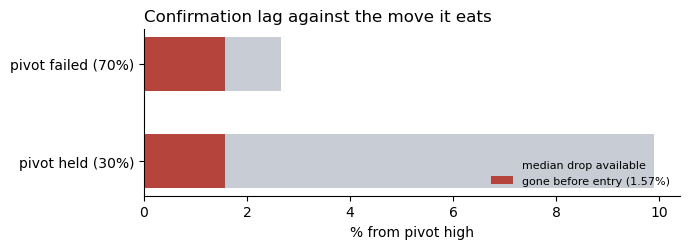

confirmation lag 1.57%  vs median failed drop 2.66%


In [5]:
import matplotlib.pyplot as plt

held_mask = p["bars_held"].isna()
hi   = p["bar"].map(lambda b: df["high"].iloc[int(b)])
cl   = p["bar"].map(lambda b: df["close"].iloc[int(b) + 1])
lag  = ((hi - cl) / hi * 100).mean()
held   = p[held_mask]["max_drop"].median()
failed = p[~held_mask]["max_drop"].median()
labels = ["pivot held (30%)", "pivot failed (70%)"]

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(labels, [held, failed], color="#c8ccd4", height=.55,
        label="median drop available")
ax.barh(labels, [lag, lag], color="#b4443c", height=.55,
        label=f"gone before entry ({lag:.2f}%)")
ax.set_xlabel("% from pivot high")
ax.set_title("Confirmation lag against the move it eats", loc="left")
ax.legend(frameon=False, fontsize=8, loc="lower right")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("confirmation_lag.png", dpi=150)
plt.show()

print(f"confirmation lag {lag:.2f}%  vs median failed drop {failed:.2f}%")